# Tutorial PXCT data analysis (PART 1)

### Tutor: Julio C. da Silva (Néel Institute CNRS, Grenoble, France) 
### email: julio-cesar.da-silva@neel.cnrs.fr
#### Personal webpage: https://sites.google.com/view/jcesardasilva

### <span style="color:red">** Disclaimer: This notebook is intended from educational reasons only.**</span>

<table class="tfo-notebook-buttons" align="center">
    
  <td>
    <a target="_blank" rel="noopener noreferrer" href="https://github.com/jcesardasilva/tutorialHercules.git"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
   </td>
    
</table>

**All the steps of this processing pipeline are described in:**

*da Silva, J. C., Haubrich, J., Requena, G., Hubert, M., Pacureanu, A., Bloch, L., Yang, Y., Cloetens, P., “High energy near-and far-field ptychographic tomography at the ESRF”. Proc. SPIE 10391, Developments in X-Ray Tomography XI, 1039106 (2017). [doi: 10.1117/12.2272971](https://doi.org/10.1117/12.2272971)*

**REMARKS: the references of this paper contains a list of important and more pioneering works on the PXCT data processing steps**

### Toupy - Tomographic Utilities for Python

<table class="tfo-notebook-buttons" align="center">

  <td>
    <a target="_blank" rel="noopener noreferrer"
href="https://toupy.readthedocs.io"><img src="https://toupy.readthedocs.io/en/latest/_static/toupy_logo.png" width="20%"/></a>
  </td>
</table>

**For the PXCT data analysis, we will use the python suite [*Toupy*](https://toupy.readthedocs.io/), which is maintained by me, but open to contributions from the community.**

In [1]:
#!pip install --user git+https://github.com/jcesardasilva/toupy.git# uncomment this line if not installed

Importing the dependencies:

In [2]:
%matplotlib widget
# standard packages
import os
import tarfile
import sys
# third party packages
import matplotlib.pyplot as plt
import numpy as np
import toupy

CuPy not found: GPU reconstruction unavailable, falling back to CPU.


#### Loading the data
We now load the data. We will use a dataset we obtained at cSAXS beamline (PSI, CH) by applying PXCT on the characterizationn of a shaped Fluid Catalytic Cracking (FCC) catalyst. The open-access publication from 2015 can be found [here](https://doi.org/10.1002/cctc.201402925)*. FCC catalysts are important shaped catalysts for the oil industry which enable the conversion of crude oil (petroleum) into more valuable products (E.g. gasoline, olefinic gases).

***da Silva, J. C., Mader, K., Holler, M., Haberthür, D., Diaz, A., Guizar-Sicairos, M., Cheng, W-.C., Shu, Y., Raabe, J., Menzel, A., van Bokhoven, J. A., “Assessment of the 3D pore structure and individual components of preshaped catalyst bodies by X-ray imaging”, ChemCatChem 7, 413-416 (2015)**

The data should be in the file named `PXCTprojections.npz`, which contains the complex number PXCT projections. First, download the file from the internet (uncomment the lines below to do so):

In [3]:
import zenodo_get
###-----------
download_file = True
###-----------
if download_file:
    zenodoID = '15364581'
    zenodo_get.download(zenodoID)

<span style="color:red"> **Remark:**
For the sake of speed and to reduce the computing resources required for this tutorial, the projections have been downsized (binned) by a factor 2, which also means the pixel size is twice larger than the original pixel size. Nevertheless, this does not affect the data processing step, which should be identical for the original dataset. </span>

We can now load the data from the file:

In [4]:
fname = "PXCTprojections.npz"
data_dict = np.load(fname) # load the file
list(data_dict.files) # this one list the keys of the data dictionary extracted from the file

['wavelen', 'psize', 'projections', 'theta']

You can, for example, get the wavelength of the pixel size:

In [5]:
wavelen = data_dict['wavelen']
pixsize = data_dict['psize']

print(f"The projection pixel size of the projections is {pixsize/1e-9:.02f} nm")
print(f"The wavelenth of the incoming photons is {wavelen/1e-10:.02f} Angstroms")

The projection pixel size of the projections is 28.64 nm
The wavelenth of the incoming photons is 2.00 Angstroms


We should also get the tomographic angles (`theta`) and the complex-valued projections, from which we should extract only the phases:

In [6]:
theta = data_dict['theta']
projections = data_dict['projections'] # <- ATTENTION: this one is memory consuming. 
projections = np.angle(projections).astype(np.float32) # Get the phases of the complex-valued projections 
nproj, nr, nc = projections.shape

In [7]:
delta_theta = np.diff(np.sort(theta))[0]
delta_theta_subtomo = np.diff(theta)[0]
print(f"The angular sampling interval is {delta_theta:.02f} degrees")
print(f"The angular sampling interval within each subtomo is {delta_theta_subtomo:.02f} degrees")

The angular sampling interval is 0.40 degrees
The angular sampling interval within each subtomo is 3.20 degrees


Text(0, 0.5, 'angle (degrees)')

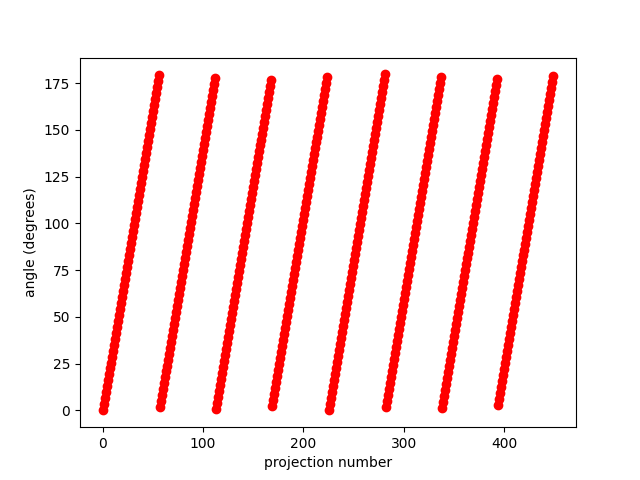

In [8]:
plt.plot(theta,'ro')
plt.xlabel('projection number')
plt.ylabel('angle (degrees)')

#### Let us take a look at one projection. I will select the first and last ones,i.e. at angles 0 and 180-$\Delta\theta$ degress:

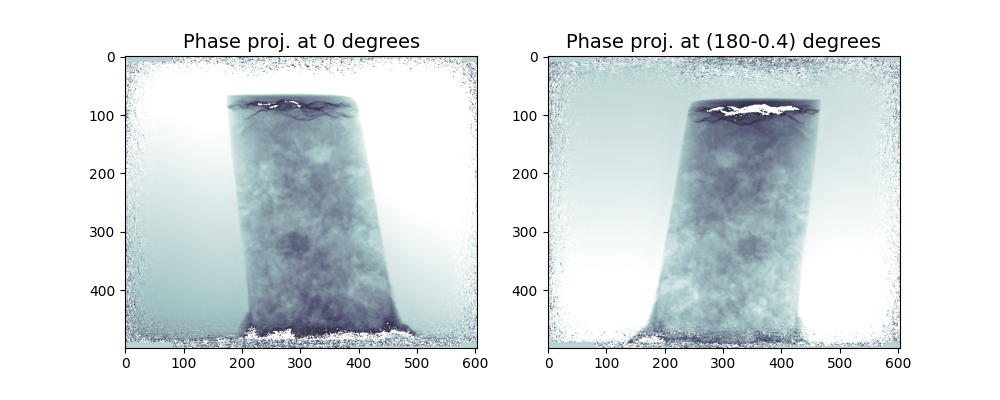

In [9]:
plt.close('all')
fig1 = plt.figure(1,figsize=(10,4))
ax1 = fig1.add_subplot(121)
im1 = ax1.imshow(projections[0],cmap='bone', vmin=-4, vmax=1)
ax1.set_title('Phase proj. at 0 degrees',fontsize = 14)
ax2 = fig1.add_subplot(122)
im2 = ax2.imshow(projections[-1],cmap='bone', vmin=-4, vmax=1)
ax2.set_title('Phase proj. at (180-0.4) degrees',fontsize = 14)
plt.show(block=False)

#### Removing linear phase ramp
You may have notice the linear phase ramp in the image. The first step of the PXCT data analysis is correcting for that ramp as we do below. 

**Toupy** provides an iterative environment for selecting the mask area, but it is complicated to use in Jupyter notebooks, unfortunately. Otherwise, one could use the commented lines below:

In [10]:
from toupy.restoration import make_air_mask

In [ ]:
painter = make_air_mask(projections[0], cmap='bone', vmin=-1.6, vmax=1.6)

In [ ]:
air_mask = painter.mask.copy()
plt.figure(),plt.imshow(air_mask),plt.show()

So, instead of the interactive plot, let us do it manually. Let us first plot one projection to look at the ramp and air area:

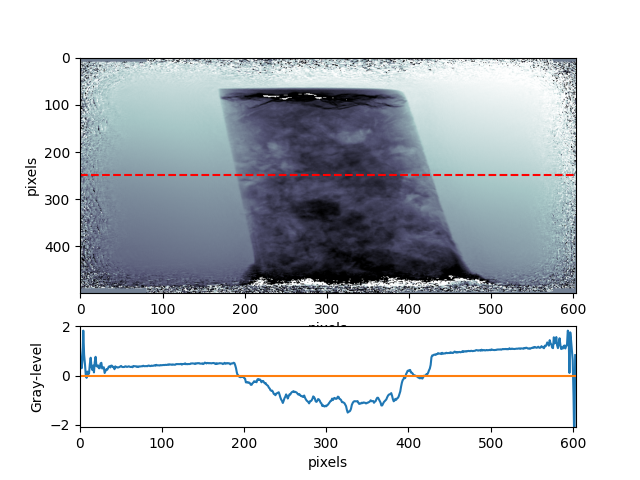

In [11]:
import matplotlib.gridspec as gridspec
#-----------
# parameters
#------------
projnum = 1 # projection number
pvmin = -2.1 # gray scale minimum value
pvmax = 2 # gray scale maximum value
#------------
# Displaying the images
fig2 = plt.figure(2)#,figsize=(6,8))
plt.clf()
gs = gridspec.GridSpec(
        2, 1, width_ratios=[4], height_ratios=[7,3]  # figure=4,
    )
ax1 = plt.subplot(gs[0])
im1 = ax1.imshow(projections[projnum],cmap="bone",vmin=pvmin,vmax=pvmax)
ax1.axis('tight')
ax1.plot([0,nc],[int(nr/2),int(nr/2)],'r--')
ax1.set_xlabel('pixels')
ax1.set_ylabel('pixels')
ax2 = plt.subplot(gs[1])
im2 = ax2.plot(projections[projnum,int(nr/2),:])
ax2.plot([0,nc],[0,0])
ax2.set_xlim([0,nc])
ax2.set_ylim([pvmin,pvmax])
ax2.set_xlabel('pixels')
ax2.set_ylabel('Gray-level')
#plt.savefig('before_rmphaseramp.png')
plt.show()

#### Creating the mask
We should create a mask containing only area with air/vacuum around the sample:

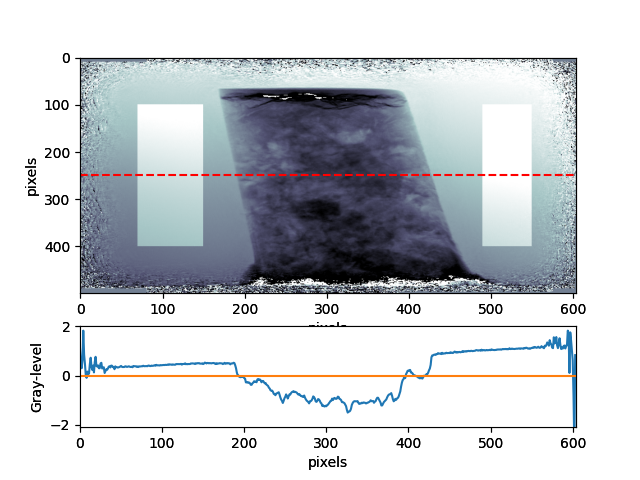

In [12]:
maskair = np.zeros_like(projections[0])
maskair[100:400,70:150]=1
maskair[100:400,490:550]=1
#-----------
# parameters
#------------
projnum = 1 # projection number
pvmin = -2.1 # gray scale minimum value
pvmax = 2 # gray scale maximum value
#------------

# Displaying the images
fig2 = plt.figure(2)#,figsize=(6,8))
gs = gridspec.GridSpec(
        2, 1, width_ratios=[4], height_ratios=[7,3]  # figure=4,
    )
ax1 = plt.subplot(gs[0])
im1 = ax1.imshow(projections[projnum]+maskair,cmap="bone",vmin=pvmin,vmax=pvmax)
ax1.axis('tight')
ax1.plot([0,nc],[int(nr/2),int(nr/2)],'r--')
ax1.set_xlabel('pixels')
ax1.set_ylabel('pixels')
ax2 = plt.subplot(gs[1])
im2 = ax2.plot(projections[projnum,int(nr/2),:])
ax2.plot([0,nc],[0,0])
ax2.set_xlim([0,nc])
ax2.set_ylim([pvmin,pvmax])
ax2.set_xlabel('pixels')
ax2.set_ylabel('Gray-level')
plt.show(block=False)

#### Applying the mask
Let us apply the mask to one projection

In [13]:
from toupy.restoration import rmlinearphase, rmphaseramp, normalize_projections_phase
from toupy.utils import tqdm

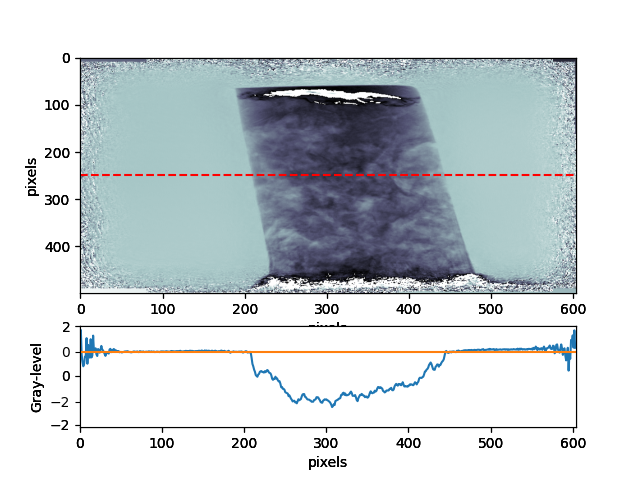

In [14]:
#-----------
# parameters
#------------
projnum = 150 # projection number
pvmin = -3 # gray scale minimum value
pvmax = 1 # gray scale maximum value
#------------
imgin = np.exp(1j * projections[projnum]).copy() # Deep copy
#projcorr = np.angle(rmlinearphase(imgin, maskair)).copy()
projcorr = np.angle(rmphaseramp(imgin, weight='auto', zero_air_phase=True, border=55))
#projcorr = np.angle(rmphaseramp(imgin, weight=None, zero_air_phase=True, border=55))
#projcorr = np.angle(rmphaseramp(imgin, weight=maskair, zero_air_phase=True))
#corrected, offsets = normalize_projections_phase(projcorr, border=55)
# Displaying the images again
fig2 = plt.figure(2,figsize=(6,8))
gs = gridspec.GridSpec(
        2, 1, width_ratios=[4], height_ratios=[7,3]  # figure=4,
    )
ax1 = plt.subplot(gs[0])
#im1 = ax1.imshow(projcorr+maskair,cmap="bone",vmin=pvmin,vmax=pvmax)
im1 = ax1.imshow(projcorr,cmap="bone",vmin=pvmin,vmax=pvmax)
#im1 = ax1.imshow(corrected,cmap="bone",vmin=pvmin,vmax=pvmax)
ax1.axis('tight')
ax1.plot([0,nc],[int(nr/2),int(nr/2)],'r--')
ax1.set_xlabel('pixels')
ax1.set_ylabel('pixels')
ax2 = plt.subplot(gs[1])
im2 = ax2.plot(projcorr[int(nr/2),:])
ax2.plot([0,nc],[0,0])
ax2.set_xlim([0,nc])
ax2.set_ylim([pvmin,pvmax])
ax2.set_xlabel('pixels')
ax2.set_ylabel('Gray-level')
plt.show(block=False)

#### Great! It works. So, we can proceed with all the other projections:

In [15]:
projcorr = np.empty_like(projections)
pbar = tqdm(range(nproj), desc="Processing projection", colour='blue', file=sys.stdout)
for ii in pbar:
    #pbar.set_description(f'Processing projection {ii} out of {nproj}')
    imgin = np.exp(1j * projections[ii]).copy() # Deep copy
    #projcorr[ii] = np.angle(rmlinearphase(imgin, maskair)).copy()
    projcorr[ii] = np.angle(rmphaseramp(imgin, weight='auto', zero_air_phase=True, border=55))
    #projcorr[ii] = np.angle(rmphaseramp(imgin, weight=maskair, zero_air_phase=True))

Processing projection: 100%|████████████████████████████████████| 450/450 [00:10<00:00, 42.34it/s]


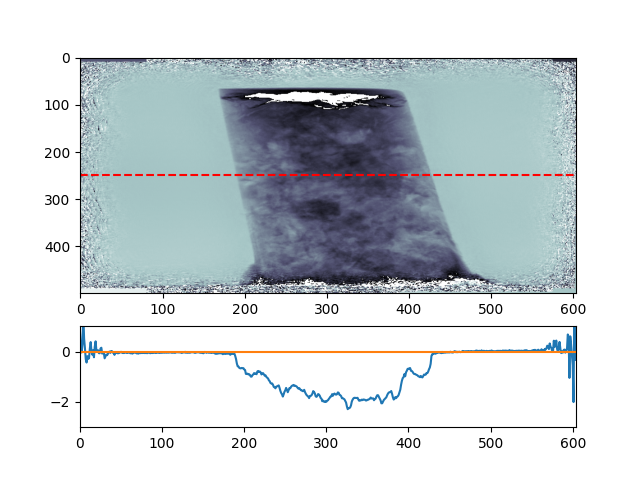

In [16]:
# Do you want to check the results? Take a look:
#-----------
# parameters
#------------
projnum = 1 # projection number
pvmin = -3 # gray scale minimum value
pvmax = 1 # gray scale maximum value
#------------

# Displaying the images
fig2 = plt.figure(2,figsize=(6,8))
plt.clf()
gs = gridspec.GridSpec(
        2, 1, width_ratios=[4], height_ratios=[7,3]  # figure=4,
    )
ax1 = plt.subplot(gs[0])
im1 = ax1.imshow(projcorr[projnum],cmap="bone",vmin=pvmin,vmax=pvmax)
ax1.axis('tight')
ax1.plot([0,nc],[int(nr/2),int(nr/2)],'r--')
ax2 = plt.subplot(gs[1])
im2 = ax2.plot(projcorr[projnum,int(nr/2),:])
ax2.plot([0,nc],[0,0])
ax2.set_xlim([0,nc])
ax2.set_ylim([pvmin,pvmax])
plt.show()

In [17]:
from toupy.restoration import rmphaseramp, normalize_projections_phase

sinogram = projcorr[:,300,:]
argangle = np.argsort(theta)
sinosort = sinogram[argangle]

corrected, offsets = normalize_projections_phase(projcorr, border=55)
sinogram_norm = corrected[:,300,:]
sinosort_norm = sinogram_norm[argangle]

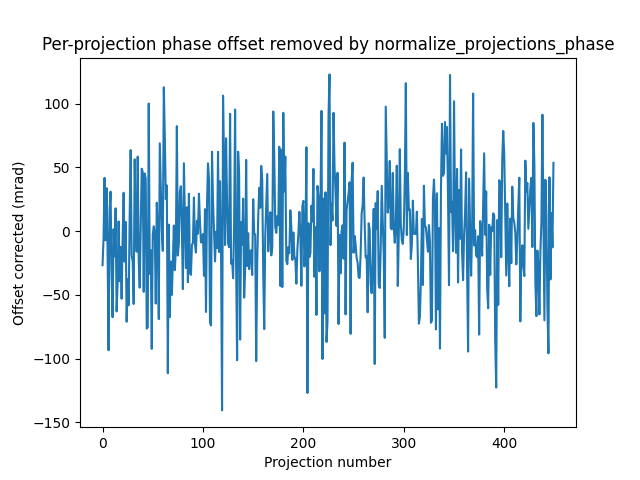

In [18]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(offsets * 1e3)
plt.xlabel('Projection number')
plt.ylabel('Offset corrected (mrad)')
plt.title('Per-projection phase offset removed by normalize_projections_phase')
plt.show()

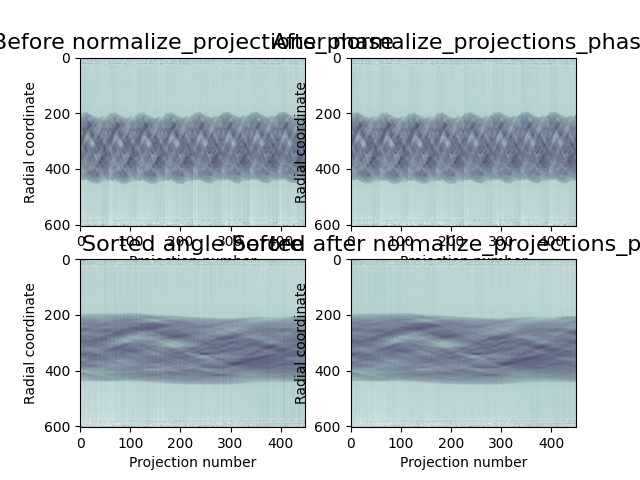

In [19]:
# preparing figure canvas
plt.close('all')
fig4 = plt.figure(4)#, figsize = (12,12))
ax41 = fig4.add_subplot(221)
im41 = ax41.imshow(sinogram.T,cmap='bone', vmin = -4, vmax = 1)
ax41.set_xlabel('Projection number')
ax41.set_ylabel('Radial coordinate')
ax41.set_title('Before normalize_projections_phase', fontsize = 16)
ax41.axis('tight')
ax42 = fig4.add_subplot(222)
im42 = ax42.imshow(sinogram_norm.T,cmap='bone', vmin = -4, vmax = 1)
ax42.set_xlabel('Projection number')
ax42.set_ylabel('Radial coordinate')
ax42.set_title('After normalize_projections_phase', fontsize = 16)
ax42.axis('tight')
ax42 = fig4.add_subplot(223)
im42 = ax42.imshow(sinosort.T,cmap='bone', vmin = -4, vmax = 1)
ax42.set_xlabel('Projection number')
ax42.set_ylabel('Radial coordinate')
ax42.set_title('Sorted angle before', fontsize = 16)
ax42.axis('tight')
ax42 = fig4.add_subplot(224)
im42 = ax42.imshow(sinosort_norm.T,cmap='bone', vmin = -4, vmax = 1)
ax42.set_xlabel('Projection number')
ax42.set_ylabel('Radial coordinate')
ax42.set_title('Sorted after normalize_projections_phase', fontsize = 16)
ax42.axis('tight')
plt.show(block=False)

#### Phase unwrapping
Although there are very few area where the phases are wrapped, it will be benefitial to unwrap them.

In [20]:
# import the toupy routines we will need
from toupy.restoration import phaseresidues, chooseregiontounwrap, unwrap_phase_2d, unwrapping_phase
from toupy.utils import iterative_show

Checking for phase residues …


Searching phase residues: 100%|████████████████████████████████| 450/450 [00:02<00:00, 154.62it/s]

. Done
→ residue map done.
Step 1/3: click the TOP-LEFT corner of the unwrap region


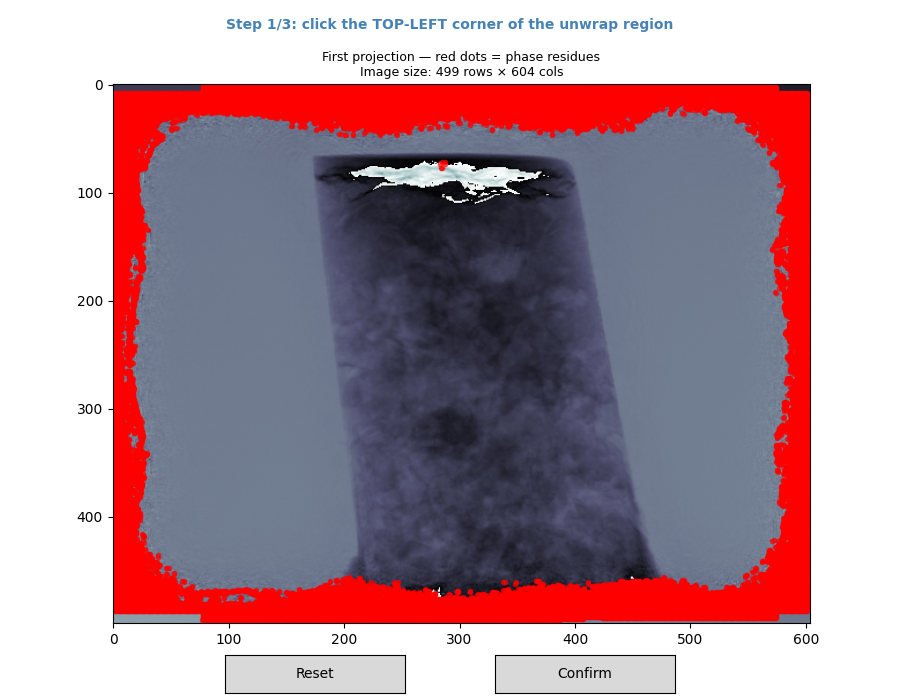


Jupyter two-cell workflow:
  Interact with the figure above (3 clicks + Confirm),
  then run in the NEXT cell:
      rx, ry, airpix = picker.rx, picker.ry, picker.airpix


In [21]:
# find the residues and choose a region to be unwrapped
picker = chooseregiontounwrap(corrected)

In [22]:
rx, ry, airpix = picker.rx, picker.ry, picker.airpix
print(rx, ry, airpix)   # sanity check

range(55, 554) range(54, 451) (104, 100)


### Different 2D phase unwrap methods
- Herraez (method="herraez", default) — reliability-guided BFS using a min-heap. More robust on noisy data; reliability = 1/D where D = sum of squared second-difference errors from 8 neighbours.
- Goldstein (method="goldstein") — finds phase residues, pairs them with greedy nearest-neighbour matching, draws L-shaped branch cuts, then BFS flood-fills avoiding the cuts.
- Flynn (method="flynn") — integrates wrapped horizontal differences row by row, then corrects row-to-row jumps using median discontinuity detection.
- wls — DCT-based Poisson solver (Ghiglia & Romero 1994): Solves ∇²φ = ρ globally via DCT-II transform — O(N log N), no extra dependency. Globally optimal under a uniform noise model; no greedy decisions. RMSE < 10⁻¹³ rad on both linear ramps and concentric rings. Best first upgrade to try if Herraez fails
- snaphu (Chen & Zebker 2001): The de facto gold standard.
Uses the reliability map as a coherence proxy to guide its statistical cost. Requires one extra install: pip install snaphu. Raises a clear ImportError with install instructions if not present

Testing unwrapping on the first projection …
→ done.
Displaying first unwrapped projection (vmin=-3, vmax=1).
If the color scale needs adjusting, stop here, update params['vmin'] / params['vmax'] and re-run.


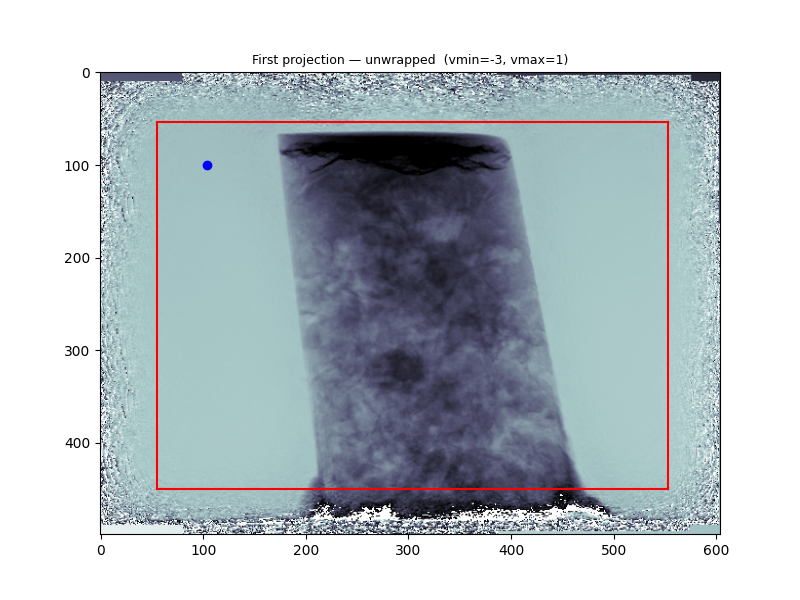

Parallel unwrapping using 4 cpus


Unwrapping projections: 100%|███████████████████████████████████| 450/450 [01:39<00:00,  4.53it/s]


Correcting for air values


In [25]:
params = dict() # initializing dictionary
params["unwrap_method"] = "herraez"    # default — reliability-guided BFS
#params["unwrap_method"] = "goldstein"  # branch-cut + flood fill
#params["unwrap_method"] = "flynn"      # row-integration (fastest, least robust)
#params["unwrap_method"] = "wls"        # DCT-Poisson least squares ← NEW
#params["unwrap_method"] = "snaphu"     # statistical network-flow   ← NEW (needs: pip install snaphu)
params["parallel"]=True
params["n_cpus"]= 4
params["vmin"]= pvmin
params["vmax"]= pvmax
projunwrap = unwrapping_phase(projcorr, rx, ry, airpix, **params)

#### Let us save our progress so far and make a break for discution/questions

In [ ]:
outputfname = "PXCTcorrprojections.npz"
np.savez(outputfname, wavelen = wavelen, psize = pixsize, projections = projunwrap, theta = theta)

In [ ]:
!ls -lrth